# Quantum Query Algorithms

## Query Model of Computation

A typical computational model includes three main components: input provided at once, computation or processing, and output. However, the Query Model is different in terms of the way the input is made available. The computing process must query an input function to gain information regarding the input. The input function acts as a blackbox and can be thought of as giving random access to various parts of the whole input. The efficiency of Query algorithms can be determined in simple terms by counting the number of times the computation queries the input function.

In quantum circuits, input functions are represented as unitary gates. The gates receive the query $a$ and an ancilla $b$ in the form $|b\rangle|a\rangle$ and outputs $|b \oplus f(a)\rangle|a\rangle$.

## Deutsch's algorithm

- Objective, given an input function $fx(): \sum \rightarrow \sum$, determine whether it is constant or balanced.
- The function takes one bit as input and outputs one bit.
- For all input combinations, a **constant** function produces the same output.
- For all input combinations, a **balanced** function produces an equal number of 0 and 1.

**Deutsch Circuit**

<img src="./diagrams/Deutsch-circuit.svg" width="500" />

In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

In [16]:
# The oracle function

def deutsch_function(case: int):
    # This function generates a quantum circuit for one of the 4 functions
    # from one bit to one bit

    if case not in [1, 2, 3, 4]:
        raise ValueError("`case` must be 1, 2, 3, or 4.")

    f = QuantumCircuit(2)
    if case in [2, 3]:
        f.cx(0, 1)
    if case in [3, 4]:
        f.x(1)
    return f

Breakdown of the four cases:

**Case 1: Constant zero function**

|a|f(a)|
|---|---|
|0|0|
|1|0|

Gate output: $|b \oplus 0\rangle|a\rangle$ = $|b\rangle|a\rangle$

**Case 2: Identity function**

|a|f(a)|
|---|---|
|0|0|
|1|1|

Gate output:

if a = 0, $|b \oplus 0\rangle|a\rangle$ = $|b\rangle|a\rangle$

if a = 1, $|b \oplus 1\rangle|a\rangle$ = $| \neg b\rangle|a\rangle$

**Case 3: NOT function**

|a|f(a)|
|---|---|
|0|1|
|1|0|

Gate output:

if a = 0, $|b \oplus 1\rangle|a\rangle$ = $| \neg b\rangle|a\rangle$

if a = 1, $|b \oplus 0\rangle|a\rangle$ = $|b\rangle|a\rangle$

**Case 4: Constant one function**

|a|f(a)|
|---|---|
|0|1|
|1|1|

Gate output: $|b \oplus 1\rangle|a\rangle$ = $| \neg b\rangle|a\rangle$

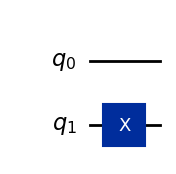

In [20]:
display(deutsch_function(4).draw(output="mpl"))

In [30]:
def compile_circuit(oracle: QuantumCircuit):
    # Compiles a circuit for use in Deutsch's algorithm.

    n = oracle.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)

    qc.x(n)
    qc.h(range(n + 1))

    qc.barrier()
    qc.compose(oracle, inplace=True)
    qc.barrier()

    qc.h(range(n))
    qc.measure(range(n), range(n))

    return qc

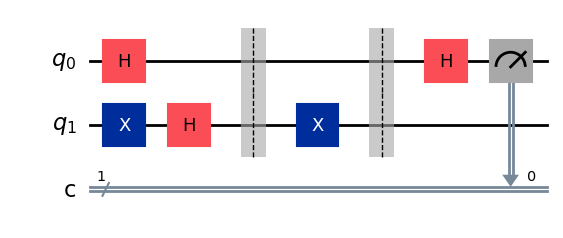

In [26]:
display(compile_circuit(deutsch_function(4)).draw(output="mpl"))

In [27]:
def deutsch_algorithm(function: QuantumCircuit):
    # Determine if a one-bit function is constant or balanced.

    qc = compile_circuit(function)

    result = AerSimulator().run(qc, shots=1, memory=True).result()
    measurements = result.get_memory()
    if measurements[0] == "0":
        return "constant"
    return "balanced"

In [28]:
f = deutsch_function(4)
display(deutsch_algorithm(f))

'constant'

## Deutsch-Jozsa Algorithm

The Deutsch-Jozsa problem is defined as follows:

- Input function: $ f: \{0, 1\}^n \rightarrow \{0, 1\} $.
- Promise: $f$ is either constant or balanced.
- Output: 0 if $f$ is constant, 1 if $f$ is balanced.

**Deutsch-Jozsa Circuit**

<img src="./diagrams/Deutsch-Jozsa.svg" width="500" />

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np

In [17]:
# The oracle function

def dj_query(num_qubits):
    # Create a circuit implementing for a query gate for a random function
    # satisfying the promise for the Deutsch-Jozsa problem.

    qc = QuantumCircuit(num_qubits + 1)

    if np.random.randint(0, 2):
        # Flip output qubit with 50% chance
        qc.x(num_qubits)
    if np.random.randint(0, 2):
        # return constant circuit with 50% chance
        return qc

    # Choose half the possible input strings
    on_states = np.random.choice(
        range(2**num_qubits),  # numbers to sample from
        2**num_qubits // 2,  # number of samples
        replace=False,  # makes sure states are only sampled once
    )

    def add_cx(qc, bit_string):
        for qubit, bit in enumerate(reversed(bit_string)):
            if bit == "1":
                qc.x(qubit)
        return qc

    for state in on_states:
        qc.barrier()  # Barriers are added to help visualize how the functions are created.
        qc = add_cx(qc, f"{state:0b}")
        qc.mcx(list(range(num_qubits)), num_qubits)
        qc = add_cx(qc, f"{state:0b}")

    qc.barrier()

    return qc

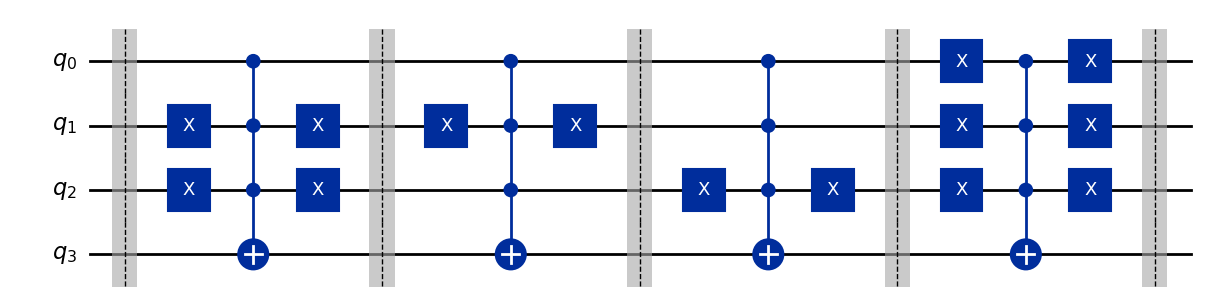

In [25]:
display(dj_query(3).draw(output="mpl"))

In [31]:
def compile_circuit(oracle: QuantumCircuit):
    # Compiles a circuit for use in the Deutsch-Jozsa algorithm.

    n = oracle.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(range(n + 1))
    qc.compose(oracle, inplace=True)
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc

In [32]:
def dj_algorithm(function: QuantumCircuit):
    # Determine if a function is constant or balanced.

    qc = compile_circuit(function)

    result = AerSimulator().run(qc, shots=1, memory=True).result()
    measurements = result.get_memory()
    if "1" in measurements[0]:
        return "balanced"
    return "constant"

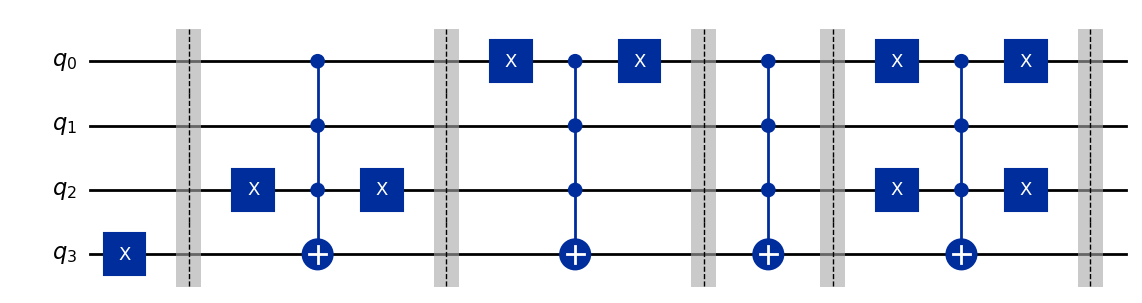

'balanced'

In [37]:
f = dj_query(3)
display(f.draw("mpl"))
display(dj_algorithm(f))

### Bernstein-Vazirani Problem

The Bernstein-Vazirani problem is defined as follows:

- Input function: $ f: \{0, 1\}^n \rightarrow \{0, 1\} $
- Promise: there exists a binary string $s = s_{n-1} \dots s_{0}$ for which $f(x) = s \cdot x$ for all $x \in \sum^n$
- Output: the string $s$

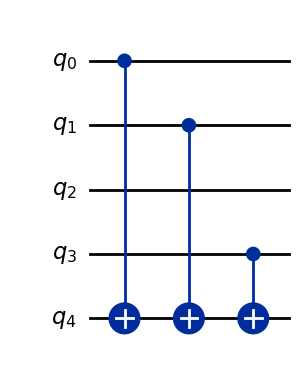

In [38]:
# The oracle function

def bv_query(s):
    # Create a quantum circuit implementing a query gate for the
    # Bernstein-Vazirani problem.

    qc = QuantumCircuit(len(s) + 1)
    for index, bit in enumerate(reversed(s)):
        if bit == "1":
            qc.cx(index, len(s))
    return qc


display(bv_query("1011").draw(output="mpl"))

In [39]:
def bv_algorithm(function: QuantumCircuit):
    qc = compile_circuit(function)
    result = AerSimulator().run(qc, shots=1, memory=True).result()
    return result.get_memory()[0]


display(bv_algorithm(bv_query("1011")))

'1011'

## Simon's Algorithm

Simon's algorithm is a quantum query algorithm for a problem known as Simon's problem.

**Simon's Problem**

---

**Input:** A function $f : \Sigma^n \rightarrow \Sigma^m$

**Promise:** There exists a string $s \in \Sigma^n$ such that $[f(x) = f(y)] \iff [(x = y) \lor (x \oplus s = y)]$ for all $x, y \in \Sigma^n$

**Output:** The string $s$

The problem consists of two cases:

1. If the string $s$ is $0^n$ then the oracle maps each input to an unique output
2. Else, the oracle maps an input $x$ along with it's pair $x \oplus s$ to an unique output

**Example oracle** for Simon's problem mapping $3$ bit inputs to $5$ bit outputs given $s = 011$. The specific value of $s$ is not relevant as long as the mapping conditions for the two cases are correct.

<img src="./diagrams/simons_oracle.png" width="200" />

In [3]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np

For the purposes of implementation, an easy way would be to map each pair of bits with an output corresponding to either one. This implementation works seamlessly for both cases of the problem.

In [44]:
pair = set()
s_num = 3

for n in range(2**3):

    # Collect pairs
    if n in pair:
        continue
    pair.add(n ^ s_num)

    # Map output to either one of the pairs
    x = f"{n:03b}"
    xs = f"{n ^ s_num:03b}"
    y = f"{n:03b}"

    if (x == xs):
        print(x, y)
    else:
        print(x, xs, y)

000 011 000
001 010 001
100 111 100
101 110 101


In [26]:
int("011", 2)

3

In [45]:
# The oracle function

def simons_oracle(input_qubits: int, output_qubits: int, s: str):

    def add_cx(qc, bit_string):
        for qubit, bit in enumerate(reversed(bit_string)):
            if bit == "0":
                qc.x(qubit)
        return qc

    def add_bit_patterns(qc, x, y):
        qc = add_cx(qc, x)
        for qubit, bit in enumerate(reversed(y)):
            if bit == "1":
                qc.mcx(list(range(input_qubits)), input_qubits + qubit)
        qc = add_cx(qc, x)
        return qc

    qc = QuantumCircuit(input_qubits + output_qubits)

    s_num = int(s, 2)

    pair = set()
    
    for n in range(2**input_qubits):
        # Collect pairs
        if n in pair:
            continue

        qc.barrier()  # Barriers are added to help visualize how the functions are created.
        pair.add(n ^ s_num)

        x = f"{n:0{input_qubits}b}"
        xs = f"{n ^ s_num:0{input_qubits}b}"
        y = f"{n:0{input_qubits}b}"

        # Add bit patterns
        qc = add_bit_patterns(qc, x, y)
        if x != xs:
            qc = add_bit_patterns(qc, xs, y)

    qc.barrier()

    return qc

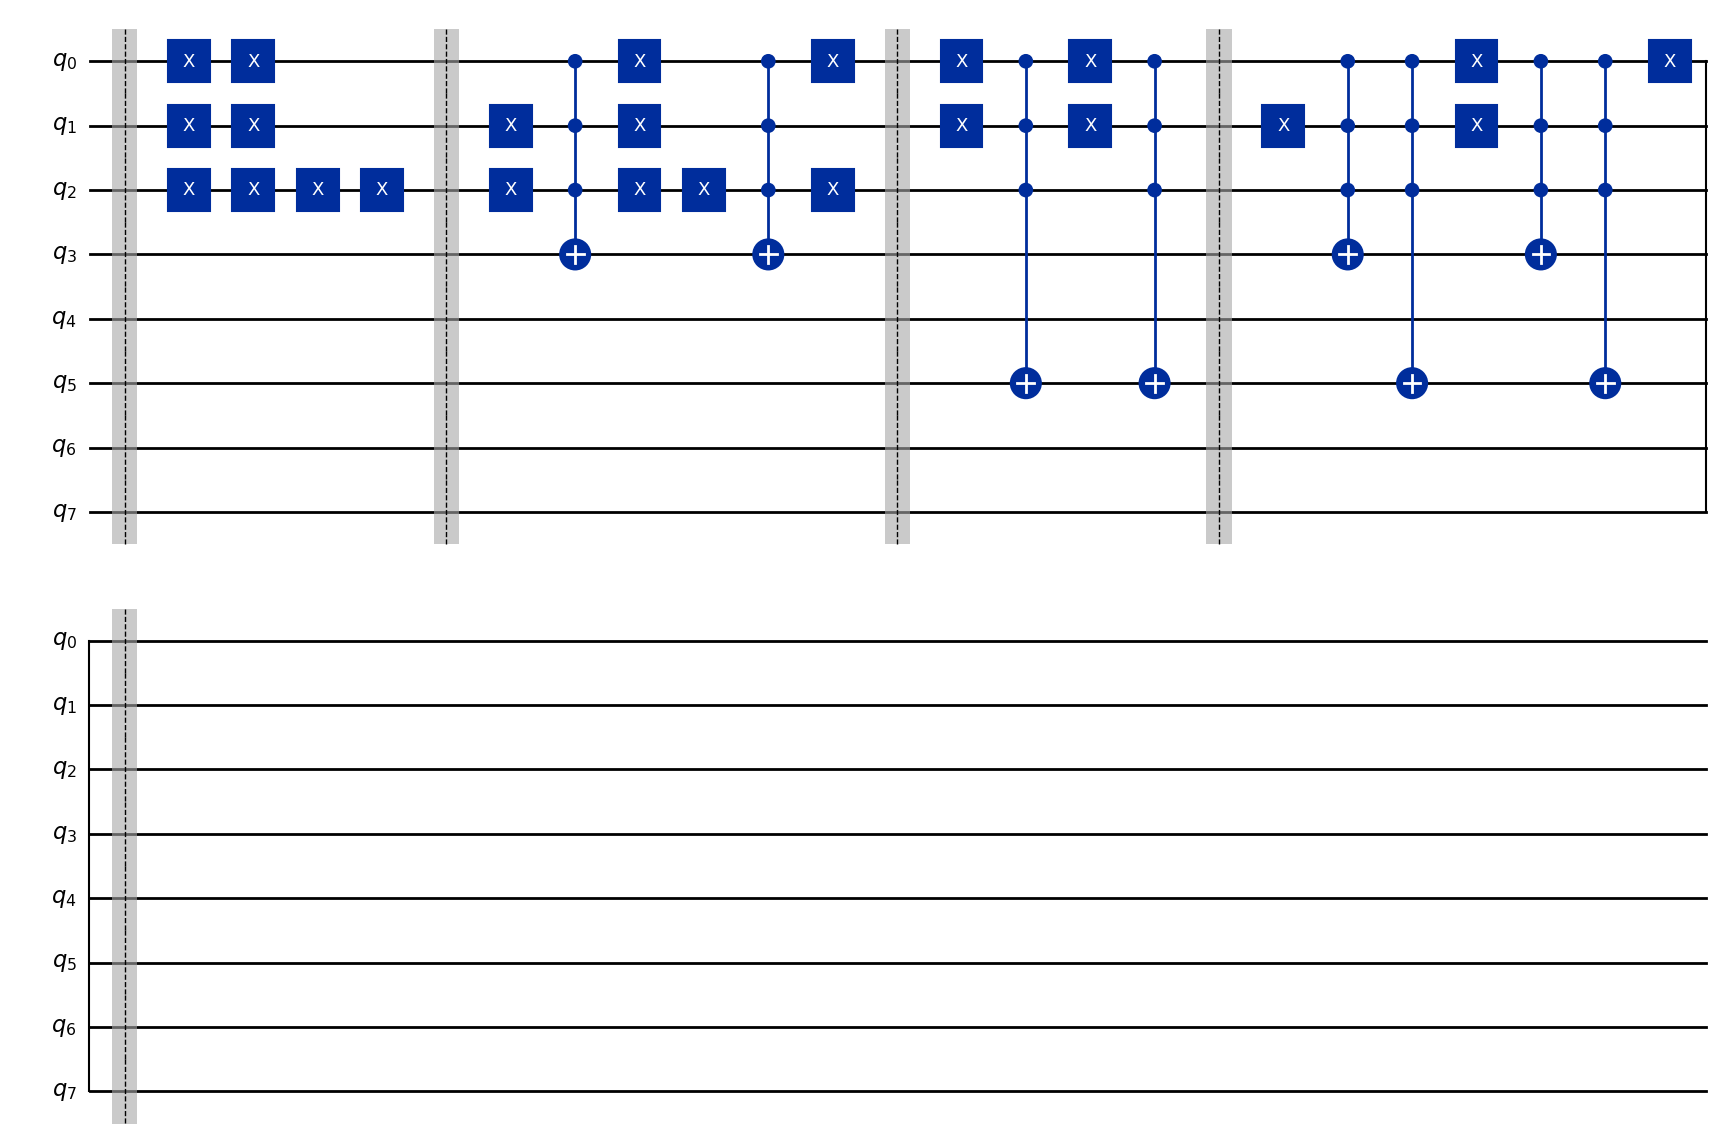

In [47]:
oracle = simons_oracle(3, 5, "011")
oracle.draw(output="mpl")

In [48]:
def compile_simons_circuit(input_qubits: int, output_qubits: int, s: str):
    # Compiles a circuit for use in Simon's algorithm.
    oracle = simons_oracle(input_qubits, output_qubits, s)

    qc = QuantumCircuit(input_qubits + output_qubits, input_qubits)
    qc.h(range(input_qubits))
    qc.compose(oracle, inplace=True)
    qc.h(range(input_qubits))
    qc.measure(range(input_qubits), range(input_qubits))

    return qc

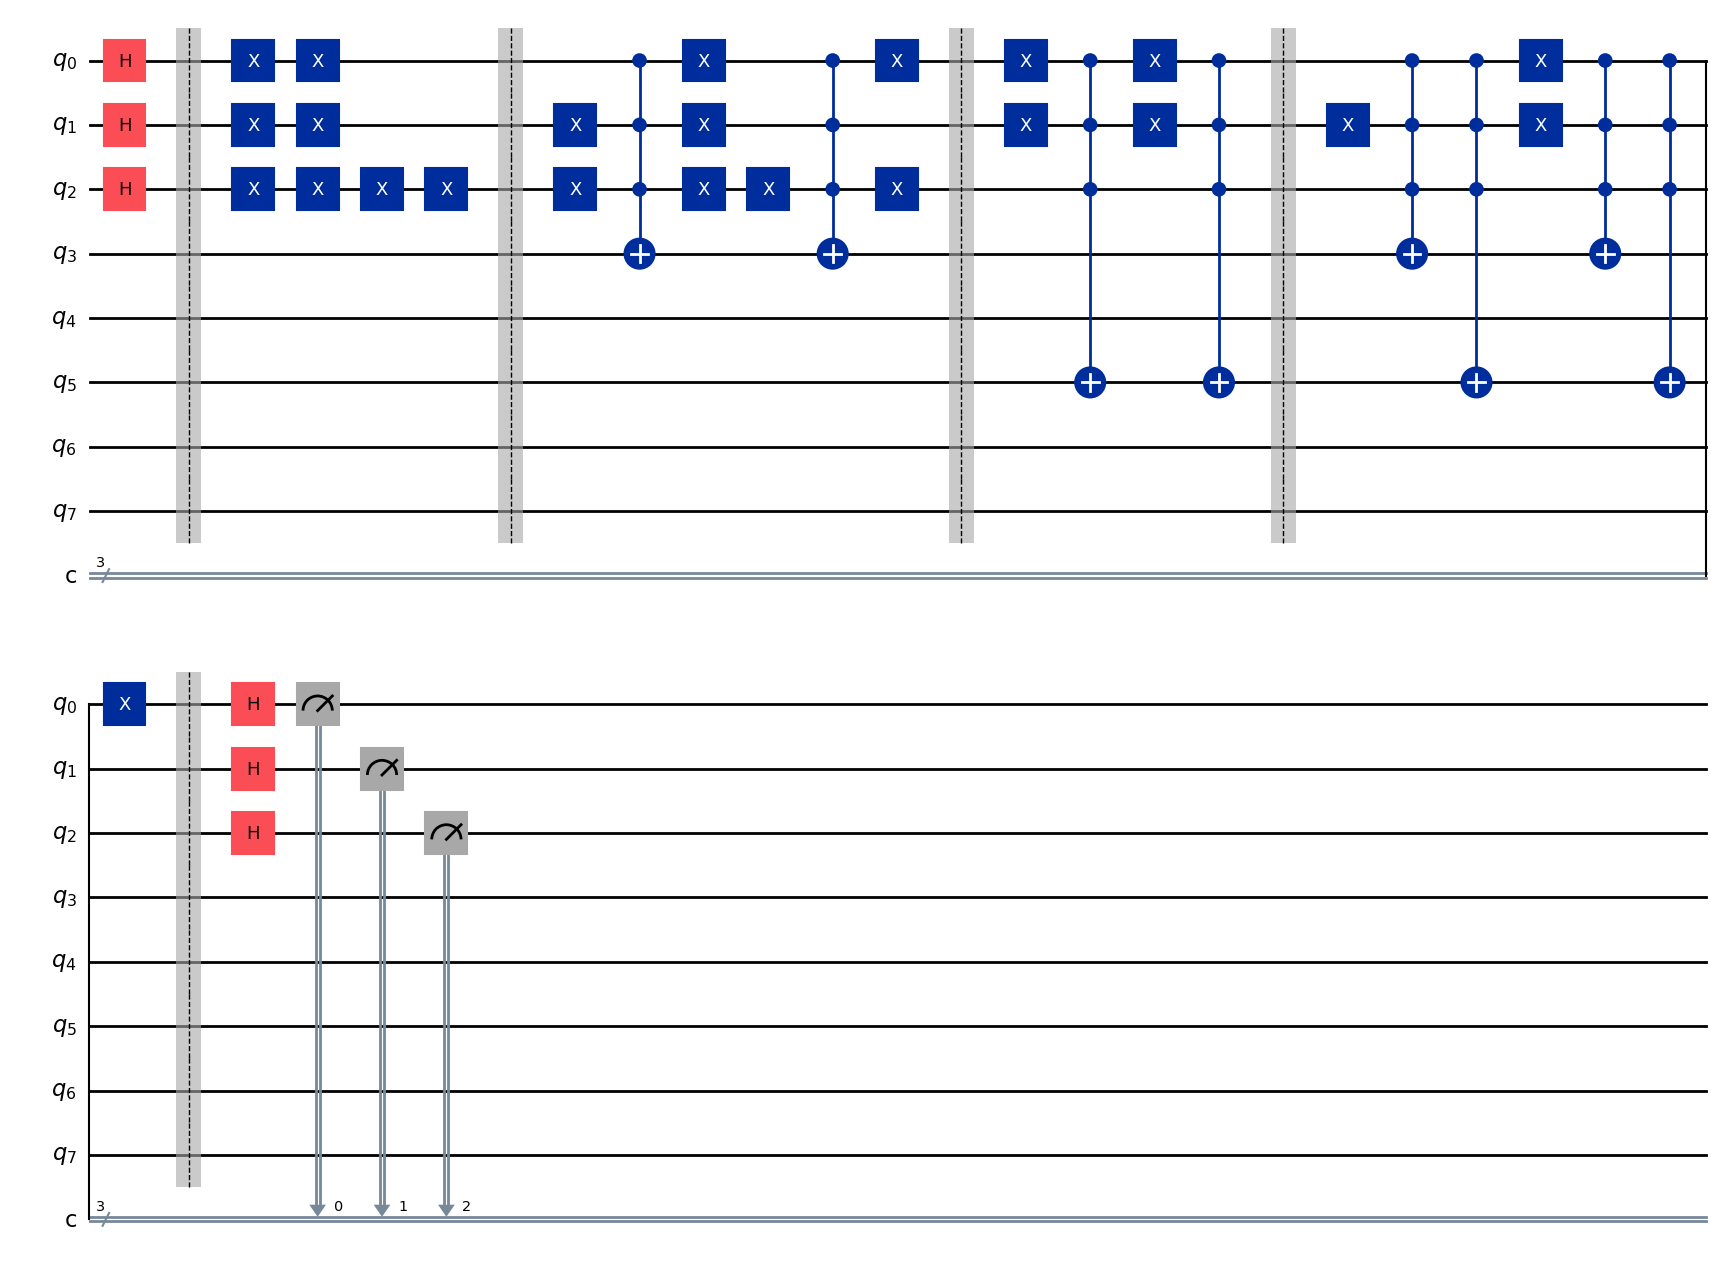

In [50]:
compile_simons_circuit(3, 5, "011").draw(output="mpl")

In [107]:
def binary_strings_to_matrix(strings):
    """
    Converts an array of binary strings into a matrix M.
    """
    return np.array([[int(bit) for bit in s] for s in strings], dtype=int)

def rref_gf2(M):
    """
    Computes the Reduced Row Echelon Form (RREF) of a matrix over GF(2).
    Returns the RREF matrix and a list of pivot columns.
    """
    A = M.copy()
    nrows, ncols = A.shape
    pivot_cols = []
    r = 0
    
    for c in range(ncols):
        if r >= nrows:
            break
            
        # Find a pivot row in the current column (from current row downwards)
        pivot_row = r + np.argmax(A[r:, c])
        if A[pivot_row, c] == 0:
            continue  # No pivot in this column, skip to the next
            
        # Swap current row with the pivot row
        if pivot_row != r:
            A[[r, pivot_row]] = A[[pivot_row, r]]
            
        pivot_cols.append(c)
        
        # Eliminate the column elements in all other rows using XOR (modulo 2 addition)
        for i in range(nrows):
            if i != r and A[i, c] == 1:
                A[i] = A[i] ^ A[r]
        r += 1
        
    return A, pivot_cols

def compute_null_space_gf2(strings):
    """
    Calculates the basis vectors for the null space of M modulo 2.
    """
    # Step 1: Preprocess matrix
    M = binary_strings_to_matrix(strings)
    nrows, ncols = M.shape
    
    # Step 2: Get Reduced Row Echelon Form
    A, pivot_cols = rref_gf2(M)
    
    # Step 3: Identify free variables
    free_cols = [c for c in range(ncols) if c not in pivot_cols]
    
    # Step 4: Construct the null space basis
    basis = []
    for f in free_cols:
        # Initialize a basis vector with 0s
        v = np.zeros(ncols, dtype=int)
        v[f] = 1  # Set the free variable to 1
        
        # Determine the dependent (pivot) variables
        for r, p in enumerate(pivot_cols):
            # In GF(2), x_p = A[r, f] * x_f simplifies directly to A[r, f]
            v[p] = A[r, f]
            
        basis.append(v)
        
    return M, A, basis

def simons_algorithm(qc: QuantumCircuit, n: int):
    # Determine s
    k = n + 10

    # Quantum Circuit Execution
    result = AerSimulator().run(qc, shots=k, memory=True).result()
    measurements = result.get_memory()

    # Classical Post-processing
    M, rref_M, null_basis = compute_null_space_gf2(measurements)

    print("Original Preprocessed Matrix M (reversed strings):")
    print(M)
    print("\nReduced Row Echelon Form (RREF) Modulo 2:")
    print(rref_M)
    print("\nBasis for the Null Space Modulo 2:")
    if len(null_basis) == 0:
        print("The null space contains only the zero vector (Empty Basis).")
    else:
        for i, vec in enumerate(null_basis):
            print(f"v_{i+1} = {vec}")
            
            # Verification: M * v should equal 0 vector mod 2
            verification = np.dot(M, vec) % 2
            assert np.all(verification == 0), f"Verification failed for v_{i+1}!"

In [114]:
string_to_guess = "010"

In [115]:
simons_algorithm(compile_simons_circuit(3, 5, string_to_guess), 3)

Original Preprocessed Matrix M (reversed strings):
[[1 0 0]
 [1 0 1]
 [0 0 0]
 [1 0 0]
 [0 0 1]
 [1 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 1]
 [0 0 1]
 [1 0 1]
 [1 0 0]
 [0 0 0]]

Reduced Row Echelon Form (RREF) Modulo 2:
[[1 0 0]
 [0 0 1]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]]

Basis for the Null Space Modulo 2:
v_1 = [0 1 0]
